# Experiment Log Trend Analysis (Synthetic)

This notebook is an exploratory, read-only analysis of accumulated agent-improvement experiment logs. It shows how an experiment history becomes an audit trail, then trend evidence, then a map of recurring failure patterns, and finally a source of better regression and evaluation datasets.

> All data here comes from `synthetic_experiment_logs.json` and is clearly labeled synthetic. Nothing in this notebook modifies the improvement framework, the production agent, or `datasets.py`.

Audit trail -> trend evidence -> recurring failure patterns -> better regression/evaluation datasets.

## Questions trend analysis can answer

- Are agent changes improving quality over time?
- Are token usage, latency, and search counts improving or worsening?
- Which failure categories occur most often?
- Which types of changes most often result in KEEP / REVERT / INVESTIGATE?
- Are regressions more common on DEV or held-out cases?
- Do patterns differ by simple / medium / complex tasks?

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True

## 1. Load and normalize the experiment records

Each record nests `observed_failure`, `dataset`, and `summary` objects. Flatten them into one row per experiment so the history is easy to analyze.

In [3]:
candidates = [
    Path('..') / 'src' / 'deep_agents_foundry' / 'synthetic_experiment_logs.json',
    Path('src') / 'deep_agents_foundry' / 'synthetic_experiment_logs.json',
    Path('synthetic_experiment_logs.json'),
]
data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not locate synthetic_experiment_logs.json')

with open(data_path, 'r', encoding='utf-8') as handle:
    payload = json.load(handle)

records = payload['records']
print('Source file:', data_path)
print('Synthetic flag:', payload.get('synthetic'))
print('Record count:', len(records))

Source file: ..\src\deep_agents_foundry\synthetic_experiment_logs.json
Synthetic flag: True
Record count: 30


In [4]:
rows = []
for record in records:
    summary = record.get('summary', {})
    dataset = record.get('dataset', {})
    failure = record.get('observed_failure', {})
    regressions = record.get('regressions', []) or []
    rows.append({
        'timestamp': record.get('timestamp'),
        'change_id': record.get('change_id'),
        'failure_category': failure.get('failure_category'),
        'failure_summary': failure.get('summary'),
        'hypothesis': record.get('hypothesis'),
        'split': dataset.get('split'),
        'cases': dataset.get('cases'),
        'complexity': dataset.get('primary_complexity'),
        'baseline_quality': summary.get('baseline_quality'),
        'candidate_quality': summary.get('candidate_quality'),
        'quality_delta': summary.get('quality_delta'),
        'baseline_success_rate': summary.get('baseline_success_rate'),
        'candidate_success_rate': summary.get('candidate_success_rate'),
        'token_delta_pct': summary.get('input_output_token_delta_pct'),
        'latency_delta_pct': summary.get('latency_delta_pct'),
        'web_search_delta': summary.get('web_search_delta'),
        'candidate_total_tokens_avg': summary.get('candidate_total_tokens_avg'),
        'candidate_latency_seconds_avg': summary.get('candidate_latency_seconds_avg'),
        'decision': record.get('decision'),
        'regressions': regressions,
        'n_regressions': len(regressions),
        'has_regression': bool(regressions),
        'notes': record.get('notes'),
    })

df = pd.DataFrame(rows)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
complexity_order = ['simple', 'medium', 'complex']
df['complexity'] = pd.Categorical(df['complexity'], categories=complexity_order, ordered=True)
print('Normalized shape:', df.shape)
df.head()

Normalized shape: (30, 23)


,timestamp,change_id,failure_category,failure_summary,hypothesis,split,cases,complexity,baseline_quality,candidate_quality,quality_delta,baseline_success_rate,candidate_success_rate,token_delta_pct,latency_delta_pct,web_search_delta,candidate_total_tokens_avg,candidate_latency_seconds_avg,decision,regressions,n_regressions,has_regression,notes
0,2026-07-01 16:00:00+00:00,prompt_search_stopping_v1-01,tool_use,Repeated or unnecessary tool/search activity,Reduce redundant searches without lowering qua...,dev,6,simple,4.0,4.06,0.06,0.72,0.73,-4.8,-2.0,-0.25,30464,41.16,KEEP,[],0,False,No material regression detected in the synthet...
1,2026-07-03 16:00:00+00:00,technology_skill_v2-02,skill,Research procedure not consistently applied,Improve architecture coverage with selective s...,dev,6,medium,4.0,4.11,0.11,0.72,0.73,0.7,4.6,-0.36,32223,43.93,KEEP,[],0,False,No material regression detected in the synthet...
2,2026-07-05 16:00:00+00:00,memory_policy_v2-03,memory,User preference handling needed refinement,Improve preference recall while avoiding accid...,dev,6,complex,4.0,4.01,0.01,0.73,0.73,-5.4,-3.0,-0.11,30272,40.74,KEEP,[],0,False,No material regression detected in the synthet...
3,2026-07-07 16:00:00+00:00,source_policy_v1-04,retrieval,Source quality or evidence coverage was incons...,Increase primary-source usage and citation qua...,held_out,3,simple,4.0,3.89,-0.11,0.73,0.72,-4.3,1.5,-0.10,30624,42.63,KEEP,[],0,False,No material regression detected in the synthet...
4,2026-07-09 16:00:00+00:00,context_compaction_v1-05,context,Repeated context increased cost or important f...,Reduce repeated context while preserving impor...,dev,6,medium,4.0,3.75,-0.25,0.74,0.71,-6.4,3.1,-0.47,29952,43.30,REVERT,[Quality regression despite lower cost],1,True,Candidate became cheaper but crossed below the...


## 2. Data-quality inspection

Before trusting any trend, confirm the shape of the data: how many experiments, the date range, missing values, and the distribution of decisions and failure categories.

In [5]:
print('Number of experiments:', len(df))
print('Date range:', df['timestamp'].min().date(), 'to', df['timestamp'].max().date())
print()
print('Missing values per column:')
print(df.isna().sum().to_string())
print()
print('Decision distribution:')
print(df['decision'].value_counts().to_string())
print()
print('Failure-category distribution:')
print(df['failure_category'].value_counts().to_string())
print()
print('Split distribution:')
print(df['split'].value_counts().to_string())

Number of experiments: 30
Date range: 2026-07-01 to 2026-08-28

Missing values per column:
timestamp                        0
change_id                        0
failure_category                 0
failure_summary                  0
hypothesis                       0
split                            0
cases                            0
complexity                       0
baseline_quality                 0
candidate_quality                0
quality_delta                    0
baseline_success_rate            0
candidate_success_rate           0
token_delta_pct                  0
latency_delta_pct                0
web_search_delta                 0
candidate_total_tokens_avg       0
candidate_latency_seconds_avg    0
decision                         0
regressions                      0
n_regressions                    0
has_regression                   0
notes                            0

Decision distribution:
decision
KEEP           23
INVESTIGATE     4
REVERT          3

Failure-category

## 3. Trend views over time

Each experiment is one point in time. Positive quality deltas favor the candidate. For token and latency deltas, negative percentages mean the candidate did less work. The orange line is a short rolling mean to make the direction easier to read.

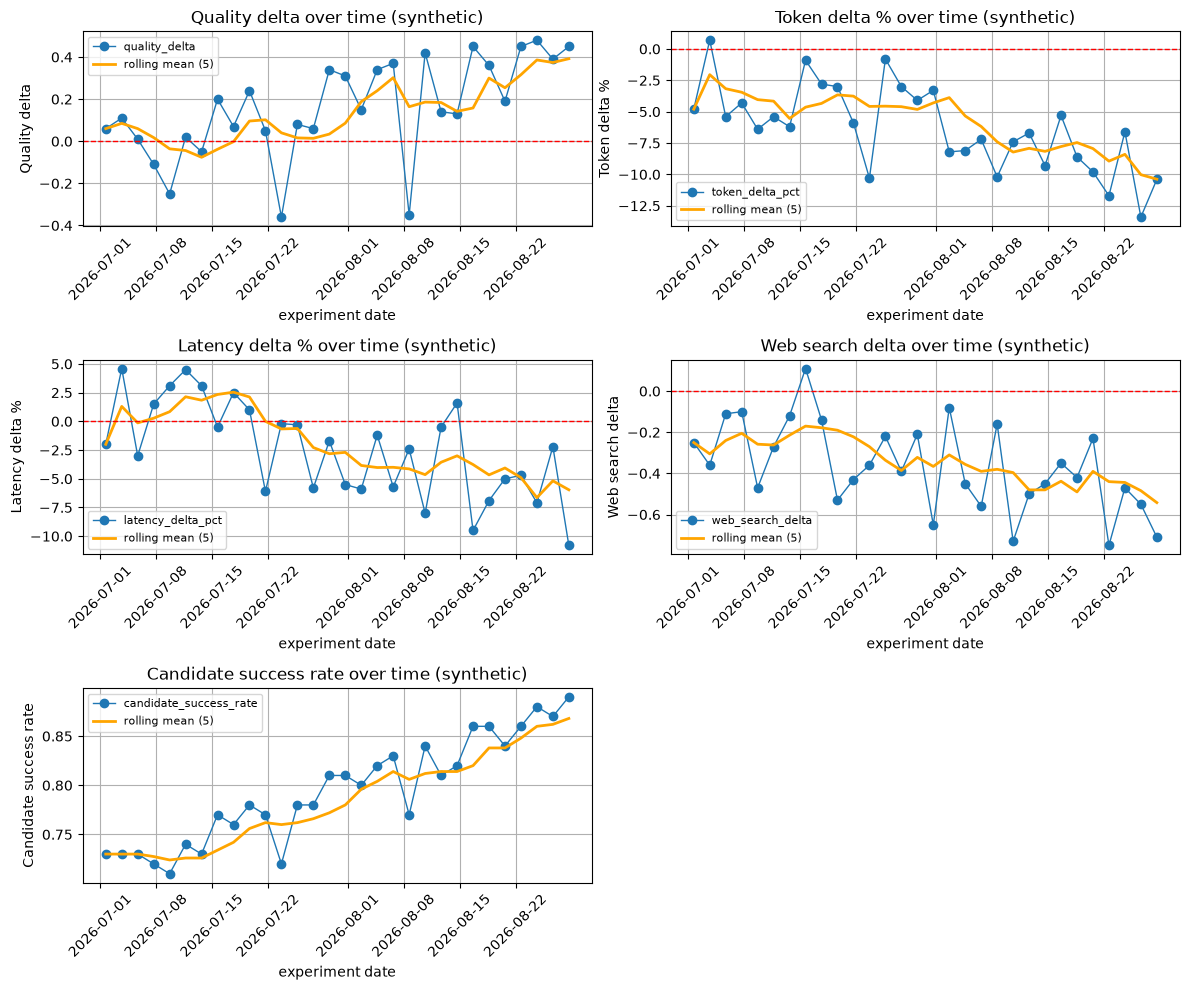

In [6]:
metrics = [
    ('quality_delta', 'Quality delta', 0.0),
    ('token_delta_pct', 'Token delta %', 0.0),
    ('latency_delta_pct', 'Latency delta %', 0.0),
    ('web_search_delta', 'Web search delta', 0.0),
    ('candidate_success_rate', 'Candidate success rate', None),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for ax, (col, label, ref) in zip(axes.flat, metrics):
    ax.plot(df['timestamp'], df[col], marker='o', linewidth=1, label=col)
    if len(df) >= 5:
        rolling = df[col].rolling(5, min_periods=1).mean()
        ax.plot(df['timestamp'], rolling, color='orange', linewidth=2, label='rolling mean (5)')
    if ref is not None:
        ax.axhline(ref, color='red', linestyle='--', linewidth=1)
    ax.set_title(label + ' over time (synthetic)')
    ax.set_xlabel('experiment date')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='best', fontsize=8)

axes.flat[-1].axis('off')
fig.tight_layout()
plt.show()

## 4. Decision analysis

How often did changes end in KEEP, REVERT, or INVESTIGATE, and what average deltas accompany each decision?

Decision counts:
decision
KEEP           23
INVESTIGATE     4
REVERT          3

Decision percentages:
decision
KEEP           76.7
INVESTIGATE    13.3
REVERT         10.0

Average deltas by decision:
             quality_delta  token_delta_pct  latency_delta_pct
decision                                                      
INVESTIGATE          0.360           -4.025             -5.650
KEEP                 0.186           -6.339             -2.217
REVERT              -0.320           -8.967              0.167


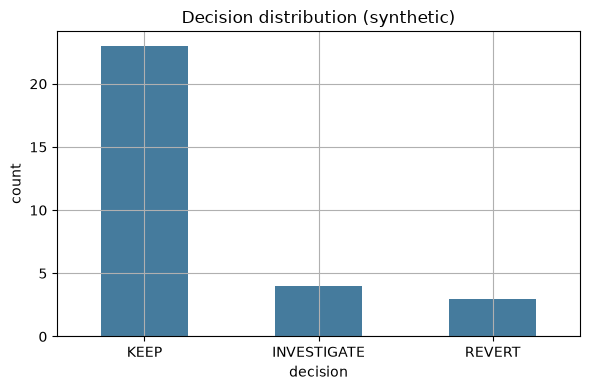

In [7]:
decision_counts = df['decision'].value_counts()
decision_pct = (decision_counts / len(df) * 100).round(1)
avg_by_decision = df.groupby('decision')[['quality_delta', 'token_delta_pct', 'latency_delta_pct']].mean().round(3)

print('Decision counts:')
print(decision_counts.to_string())
print()
print('Decision percentages:')
print(decision_pct.to_string())
print()
print('Average deltas by decision:')
print(avg_by_decision.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
decision_counts.plot(kind='bar', ax=ax, color='#457b9d')
ax.set_title('Decision distribution (synthetic)')
ax.set_xlabel('decision')
ax.set_ylabel('count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 5. Failure-category analysis

Which categories recur, how do they relate to quality, and how do they map to the final decision?

Failure-category frequency:
failure_category
tool_use     8
skill        7
memory       4
retrieval    4
context      4
subagent     3

Average quality delta by failure category:
failure_category
retrieval   -0.085
context      0.160
tool_use     0.164
skill        0.186
memory       0.220
subagent     0.320

Decision distribution by failure category:
decision          INVESTIGATE  KEEP  REVERT
failure_category                           
context                     0     3       1
memory                      0     4       0
retrieval                   1     1       2
skill                       0     7       0
subagent                    3     0       0
tool_use                    0     8       0


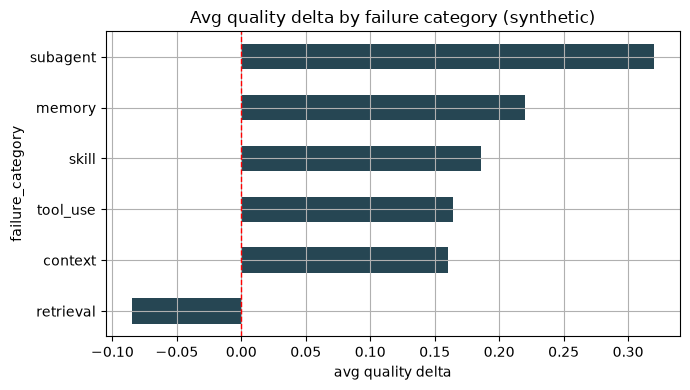

In [8]:
cat_freq = df['failure_category'].value_counts()
avg_quality_by_cat = df.groupby('failure_category')['quality_delta'].mean().round(3).sort_values()
decision_by_cat = pd.crosstab(df['failure_category'], df['decision'])

print('Failure-category frequency:')
print(cat_freq.to_string())
print()
print('Average quality delta by failure category:')
print(avg_quality_by_cat.to_string())
print()
print('Decision distribution by failure category:')
print(decision_by_cat.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
avg_quality_by_cat.plot(kind='barh', ax=ax, color='#264653')
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Avg quality delta by failure category (synthetic)')
ax.set_xlabel('avg quality delta')
plt.tight_layout()
plt.show()

## 6. Task-complexity analysis

Do simple, medium, and complex tasks respond differently to the same kinds of changes?

Average deltas by complexity:
            quality_delta  token_delta_pct  latency_delta_pct
complexity                                                   
simple              0.188            -5.15              -2.24
medium              0.068            -6.64              -1.86
complex             0.219            -7.09              -3.21

Decision distribution by complexity:
decision    INVESTIGATE  KEEP  REVERT
complexity                           
simple                2     8       0
medium                1     7       2
complex               1     8       1


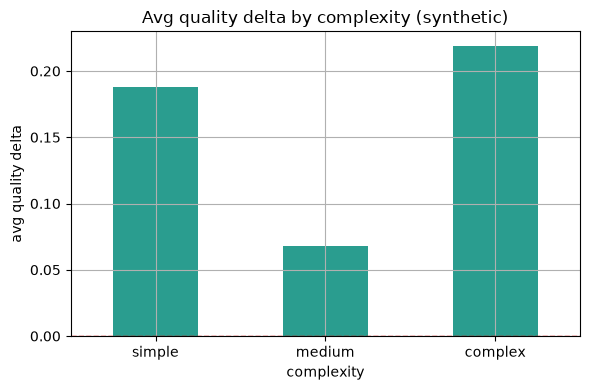

In [9]:
by_complexity = df.groupby('complexity', observed=True)[['quality_delta', 'token_delta_pct', 'latency_delta_pct']].mean().round(3)
decisions_by_complexity = pd.crosstab(df['complexity'], df['decision'])

print('Average deltas by complexity:')
print(by_complexity.to_string())
print()
print('Decision distribution by complexity:')
print(decisions_by_complexity.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
by_complexity['quality_delta'].plot(kind='bar', ax=ax, color='#2a9d8f')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Avg quality delta by complexity (synthetic)')
ax.set_ylabel('avg quality delta')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 7. DEV vs held-out behavior

Held-out cases are the stronger generalization check. Compare average quality delta, regression frequency, and KEEP rate across the two splits.

DEV vs held-out behavior (synthetic):
          experiments  avg_quality_delta  regression_freq  keep_rate
split                                                               
dev                23              0.180            0.043      0.957
held_out            7              0.089            0.857      0.143


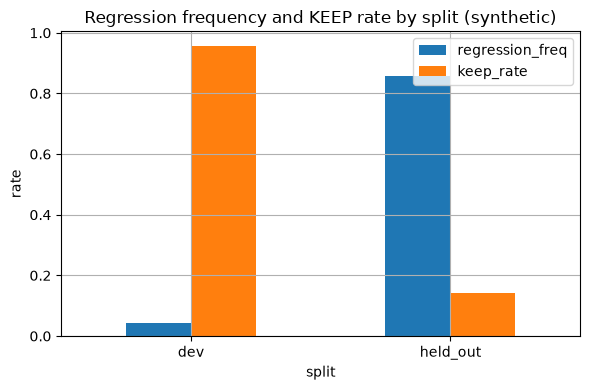

In [10]:
split_summary = df.groupby('split').agg(
    experiments=('change_id', 'count'),
    avg_quality_delta=('quality_delta', 'mean'),
    regression_freq=('has_regression', 'mean'),
    keep_rate=('decision', lambda s: (s == 'KEEP').mean()),
).round(3)

print('DEV vs held-out behavior (synthetic):')
print(split_summary.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
split_summary[['regression_freq', 'keep_rate']].plot(kind='bar', ax=ax)
ax.set_title('Regression frequency and KEEP rate by split (synthetic)')
ax.set_ylabel('rate')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 8. Recurring lessons

Synthetic patterns worth internalizing:

- Cheaper is not always better.
- Some changes improve quality but add latency.
- Certain failure categories keep recurring.
- Subagent changes can behave differently by complexity.

In [11]:
cheaper_but_worse = df[(df['token_delta_pct'] < 0) & (df['quality_delta'] < 0)]
quality_up_latency_regression = df[(df['quality_delta'] > 0) & (df['latency_delta_pct'] > 3)]
regression_patterns = df.explode('regressions')['regressions'].dropna().value_counts()
subagent_by_complexity = df[df['failure_category'] == 'subagent'].groupby('complexity', observed=True)['quality_delta'].mean().round(3)

print('Lesson 1 - cheaper is not always better:')
print(f'  {len(cheaper_but_worse)} experiment(s) reduced cost but lost quality')
print(cheaper_but_worse[['change_id', 'token_delta_pct', 'quality_delta', 'decision']].to_string(index=False))
print()
print('Lesson 2 - quality gains can hide latency regressions:')
print(f'  {len(quality_up_latency_regression)} experiment(s) improved quality but raised latency > 3%')
print(quality_up_latency_regression[['change_id', 'quality_delta', 'latency_delta_pct', 'decision']].to_string(index=False))
print()
print('Lesson 3 - recurring regression patterns:')
print(regression_patterns.to_string() if not regression_patterns.empty else '  none recorded')
print()
print('Lesson 4 - subagent behavior differs by complexity:')
print(subagent_by_complexity.to_string() if not subagent_by_complexity.empty else '  no subagent experiments')

Lesson 1 - cheaper is not always better:
  5 experiment(s) reduced cost but lost quality
               change_id  token_delta_pct  quality_delta decision
     source_policy_v1-04             -4.3          -0.11     KEEP
context_compaction_v1-05             -6.4          -0.25   REVERT
architecture_skill_v1-07             -6.2          -0.05     KEEP
     source_policy_v1-12            -10.3          -0.36   REVERT
     source_policy_v1-20            -10.2          -0.35   REVERT

Lesson 2 - quality gains can hide latency regressions:
  2 experiment(s) improved quality but raised latency > 3%
             change_id  quality_delta  latency_delta_pct decision
technology_skill_v2-02           0.11                4.6     KEEP
    tool_routing_v2-06           0.02                4.5     KEEP

Lesson 3 - recurring regression patterns:
regressions
Mixed held-out behavior                  4
Quality regression despite lower cost    3

Lesson 4 - subagent behavior differs by complexity:
complexi

## 9. How experiment logs can improve the evaluation dataset

A reproducible failure is more valuable than a one-off. When the same failure category regresses repeatedly, or a held-out case fails in a way that a change was meant to fix, that scenario is a candidate for a permanent regression case.

Promotion should be deliberate:

- A human reviews the recurring pattern.
- The scenario is reduced to a minimal, reproducible case.
- The case is added to the evaluation dataset through the normal review process.

Automatic promotion is intentionally avoided. Logs suggest; people decide. The function below only proposes candidates and never edits `datasets.py`.

In [12]:
def propose_candidate_regression_cases(
    df,
    *,
    min_recurrence=2,
    flag_revert=True,
    flag_held_out_regression=True,
    categories=None,
):
    '''Suggest candidate regression cases from historical logs.

    Read-only: returns suggestions for human review. It never edits datasets.py
    or any evaluation dataset. All inputs here are synthetic.

    Criteria (configurable):
    - a failure category recurs at least ``min_recurrence`` times
    - a change ended in a REVERT decision
    - a held-out experiment recorded a regression
    '''
    suggestions = []

    cat_counts = df['failure_category'].value_counts()
    for category, count in cat_counts.items():
        if categories is not None and category not in categories:
            continue
        if count >= min_recurrence:
            subset = df[df['failure_category'] == category]
            suggestions.append({
                'reason': 'recurring_failure_category',
                'failure_category': category,
                'recurrence_count': int(count),
                'avg_quality_delta': round(float(subset['quality_delta'].mean()), 3),
                'example_change_ids': subset['change_id'].head(3).tolist(),
            })

    if flag_revert:
        for _, row in df[df['decision'] == 'REVERT'].iterrows():
            suggestions.append({
                'reason': 'revert_decision',
                'failure_category': row['failure_category'],
                'recurrence_count': 1,
                'avg_quality_delta': round(float(row['quality_delta']), 3),
                'example_change_ids': [row['change_id']],
            })

    if flag_held_out_regression:
        held = df[(df['split'] == 'held_out') & (df['has_regression'])]
        for _, row in held.iterrows():
            suggestions.append({
                'reason': 'held_out_regression',
                'failure_category': row['failure_category'],
                'recurrence_count': 1,
                'avg_quality_delta': round(float(row['quality_delta']), 3),
                'example_change_ids': [row['change_id']],
            })

    return pd.DataFrame(suggestions)

In [13]:
proposed = propose_candidate_regression_cases(df, min_recurrence=3)
print('Proposed candidate regression cases (synthetic, suggestions only):')
print('Total suggestions:', len(proposed))
print('Reminder: these are proposals for human review; datasets.py is never modified.')
proposed

Proposed candidate regression cases (synthetic, suggestions only):
Total suggestions: 15
Reminder: these are proposals for human review; datasets.py is never modified.


,reason,failure_category,recurrence_count,avg_quality_delta,example_change_ids
0,recurring_failure_category,tool_use,8,0.164,"[prompt_search_stopping_v1-01, tool_routing_v2..."
1,recurring_failure_category,skill,7,0.186,"[technology_skill_v2-02, architecture_skill_v1..."
2,recurring_failure_category,memory,4,0.220,"[memory_policy_v2-03, memory_policy_v2-11, mem..."
3,recurring_failure_category,retrieval,4,-0.085,"[source_policy_v1-04, source_policy_v1-12, sou..."
4,recurring_failure_category,context,4,0.160,"[context_compaction_v1-05, context_compaction_..."
5,recurring_failure_category,subagent,3,0.320,"[subagent_trial_v1-08, subagent_trial_v1-16, s..."
6,revert_decision,context,1,-0.250,[context_compaction_v1-05]
7,revert_decision,retrieval,1,-0.360,[source_policy_v1-12]
8,revert_decision,retrieval,1,-0.350,[source_policy_v1-20]
9,held_out_regression,subagent,1,0.200,[subagent_trial_v1-08]


## 10. Trend Analysis Summary

A concise, human-readable synthesis of the synthetic history.

In [14]:
def _slope(series):
    values = series.to_numpy(dtype=float)
    if len(values) < 2:
        return 0.0
    return float(np.polyfit(np.arange(len(values)), values, 1)[0])

quality_slope = _slope(df['quality_delta'])
token_slope = _slope(df['token_delta_pct'])
latency_slope = _slope(df['latency_delta_pct'])

most_common_category = df['failure_category'].value_counts().idxmax()
regression_patterns = df.explode('regressions')['regressions'].dropna().value_counts()
most_common_regression = regression_patterns.idxmax() if not regression_patterns.empty else 'none recorded'
best_complexity = df.groupby('complexity', observed=True)['quality_delta'].mean().idxmax()
cheaper_but_worse = df[(df['token_delta_pct'] < 0) & (df['quality_delta'] < 0)]
quality_up_latency_regression = df[(df['quality_delta'] > 0) & (df['latency_delta_pct'] > 3)]
proposed = propose_candidate_regression_cases(df, min_recurrence=3)

keep_rate = (df['decision'] == 'KEEP').mean()
revert_rate = (df['decision'] == 'REVERT').mean()
ts_min = df['timestamp'].min().date()
ts_max = df['timestamp'].max().date()

print('=' * 64)
print('TREND ANALYSIS SUMMARY  (SYNTHETIC DATA - FOR DEMONSTRATION ONLY)')
print('=' * 64)
print(f'Experiments analyzed: {len(df)}')
print(f'Date range: {ts_min} to {ts_max}')
print()
print('Strongest trends (slope per experiment):')
print(f'  quality_delta:     {quality_slope:+.4f}  (higher is better)')
print(f'  token_delta_pct:   {token_slope:+.3f}  (lower is better)')
print(f'  latency_delta_pct: {latency_slope:+.3f}  (lower is better)')
print()
print(f'Most common failure category: {most_common_category}')
print(f'Most common regression pattern: {most_common_regression}')
print(f'Best-performing task complexity (avg quality delta): {best_complexity}')
print()
print('Warning signals:')
print(f'  cheaper-but-worse experiments: {len(cheaper_but_worse)}')
print(f'  quality-up-but-slower experiments: {len(quality_up_latency_regression)}')
print(f'  overall KEEP rate: {keep_rate:.0%}')
print(f'  overall REVERT rate: {revert_rate:.0%}')
print()
print('Candidate regression cases worth reviewing (not auto-added):')
if proposed.empty:
    print('  none under current criteria')
else:
    for _, row in proposed.iterrows():
        reason = row['reason']
        category = row['failure_category']
        count = row['recurrence_count']
        ids = ', '.join(row['example_change_ids'])
        print(f'  - [{reason}] {category} (x{count}): {ids}')
print()
print('All findings above are synthetic and for demonstration only.')

TREND ANALYSIS SUMMARY  (SYNTHETIC DATA - FOR DEMONSTRATION ONLY)
Experiments analyzed: 30
Date range: 2026-07-01 to 2026-08-28

Strongest trends (slope per experiment):
  quality_delta:     +0.0161  (higher is better)
  token_delta_pct:   -0.257  (lower is better)
  latency_delta_pct: -0.313  (lower is better)

Most common failure category: tool_use
Most common regression pattern: Mixed held-out behavior
Best-performing task complexity (avg quality delta): complex

Warning signals:
  cheaper-but-worse experiments: 5
  quality-up-but-slower experiments: 2
  overall KEEP rate: 77%
  overall REVERT rate: 10%

Candidate regression cases worth reviewing (not auto-added):
  - [recurring_failure_category] tool_use (x8): prompt_search_stopping_v1-01, tool_routing_v2-06, prompt_search_stopping_v1-09
  - [recurring_failure_category] skill (x7): technology_skill_v2-02, architecture_skill_v1-07, technology_skill_v2-10
  - [recurring_failure_category] memory (x4): memory_policy_v2-03, memory_polic